# Calendar Spread Earnings Backtest

This notebook backtests **calendar spread strategies** across earnings events.

## Strategy

For each earnings event:
1. **Entry**: Day before earnings at 3pm
2. **Position**: Sell near-term ATM option, Buy far-term ATM option (same strike)
3. **Exit**: After earnings announcement (capture IV crush)
   - AFTER_HOURS: Exit at 10am next day
   - PRE_MARKET: Exit at 4pm same day

## Goal

Determine if calendar spreads systematically profit from earnings IV crush.

In [1]:
import sys
sys.path.insert(0, '../src')

import pandas as pd
import matplotlib.pyplot as plt
from datetime import date

from dlt_ibapi.repositories import (
    EarningsCalendarReader,
    OptionBarsReader,
    EquityBarsReader
)
from dlt_ibapi.strategies import (
    filter_tradable_earnings,
    run_batch_calendar_spread_backtest,
    calculate_strategy_stats,
    format_stats_table,
    create_strategy_summary_plot,
    create_by_symbol_summary,
)

print("✅ Setup complete")

✅ Setup complete


## 1. Load and Filter Earnings Events

Load earnings data and filter to symbols with available option data.

In [2]:
# Load all earnings
earnings_reader = EarningsCalendarReader(database_path='../data_delta', dataset_name='earnings')
all_earnings = earnings_reader.get_upcoming_earnings(
    days_ahead=365,  # Get all in dataset
    from_date=date(2025, 1, 1)
)

print(f"Total earnings events: {len(all_earnings)}")
print(f"Unique symbols: {all_earnings['symbol'].nunique()}")

# Filter to symbols with option data (path is ../data_delta from notebooks folder)
option_reader = OptionBarsReader(database_path='../data_delta', dataset_name='options')
tradable_earnings = filter_tradable_earnings(all_earnings, option_reader)

print(f"\nTradable earnings (with option data): {len(tradable_earnings)}")
print(f"Symbols: {sorted(tradable_earnings['symbol'].unique())}")
print(f"\nEarnings timing:")
print(tradable_earnings['earnings_time'].value_counts())

Total earnings events: 371
Unique symbols: 370

Tradable earnings (with option data): 44
Symbols: ['AEG', 'AIRJ', 'AISP', 'AMAT', 'ANGX', 'APLT', 'AREC', 'AREN', 'ASST', 'ATER', 'ATNM', 'BAP', 'BCAB', 'BEEM', 'BETR', 'BILI', 'BITF', 'BLDP', 'BN', 'BNKK', 'BNT', 'BNTC', 'BRAG', 'BTM', 'BWEN', 'BZAI', 'BZH', 'CADL', 'CBRL', 'CBUS', 'CEPO', 'CIO', 'CLPR', 'CMBM', 'CODX', 'COSM', 'CRDL', 'CSIQ', 'CTRM', 'CTSO', 'CYBN', 'DGXX', 'DIS', 'TMC']

Earnings timing:
earnings_time
UNKNOWN        17
AFTER_HOURS    15
PRE_MARKET     12
Name: count, dtype: int64


## 2. Run Backtest Across All Earnings

Use the batch backtest function to run calendar spreads across all tradable earnings.

In [3]:
# Initialize readers
equity_reader = EquityBarsReader(database_path='../data_delta', dataset_name='stocks')

# Run batch backtest using library function
results_df = run_batch_calendar_spread_backtest(
    earnings_df=tradable_earnings,
    option_reader=option_reader,
    equity_reader=equity_reader,
    option_type='C',
    bar_size='1 hour',
    progress=True
)

print(f"\n{'='*80}")
print(f"BACKTEST COMPLETE")
print(f"{'='*80}")
print(f"Total earnings analyzed: {len(tradable_earnings)}")
print(f"Successful backtests: {len(results_df)}")
if len(tradable_earnings) > 0:
    print(f"Success rate: {len(results_df) / len(tradable_earnings) * 100:.1f}%")


Processing BNT - 2025-11-13 (UNKNOWN)...
  Spot: $43.40, ATM Strike: $43
  ⚠️  No option data for C options

Processing CTRM - 2025-11-13 (UNKNOWN)...
  Spot: $1.93, ATM Strike: $2 → Using $2.5 (nearest available), bar_size: 5 mins
  ✓ Calendar spread: Entry=$25.00, P&L=$-20.00

Processing BZH - 2025-11-13 (AFTER_HOURS)...
  Spot: $21.40, ATM Strike: $21 ✓, bar_size: 5 mins
  ⚠️  Insufficient expirations (need 2, got 1)

Processing CYBN - 2025-11-13 (PRE_MARKET)...
  Spot: $5.94, ATM Strike: $6 → Using $5.0 (nearest available), bar_size: 5 mins
  ✓ Calendar spread: Entry=$15.00, P&L=$35.00

Processing ANGX - 2025-11-13 (AFTER_HOURS)...
  Spot: $5.25, ATM Strike: $5 ✓, bar_size: 5 mins
  ✓ Calendar spread: Entry=$70.00, P&L=$-15.00

Processing BCAB - 2025-11-13 (AFTER_HOURS)...
  Spot: $0.66, ATM Strike: $1 → Using $2.5 (nearest available), bar_size: 5 mins
  ⚠️  Backtest failed: Missing entry prices

Processing BNTC - 2025-11-13 (UNKNOWN)...
  Spot: $13.15, ATM Strike: $13 → Using $12

## 3. Summary Statistics

Calculate overall statistics using library analysis functions.

In [4]:
if len(results_df) > 0:
    # Calculate and display statistics using library function
    stats = calculate_strategy_stats(results_df, pnl_column='pnl_per_contract')
    print(format_stats_table(stats, title="CALENDAR SPREAD BACKTEST RESULTS"))
else:
    print("⚠️  No successful backtests to analyze")

CALENDAR SPREAD BACKTEST RESULTS

  Count: 23 trades
  Mean P&L: $85.52
  Median P&L: $5.00
  Std Dev: $274.26
  Win Rate: 60.9%
  Best: $1260.00
  Worst: $-25.00


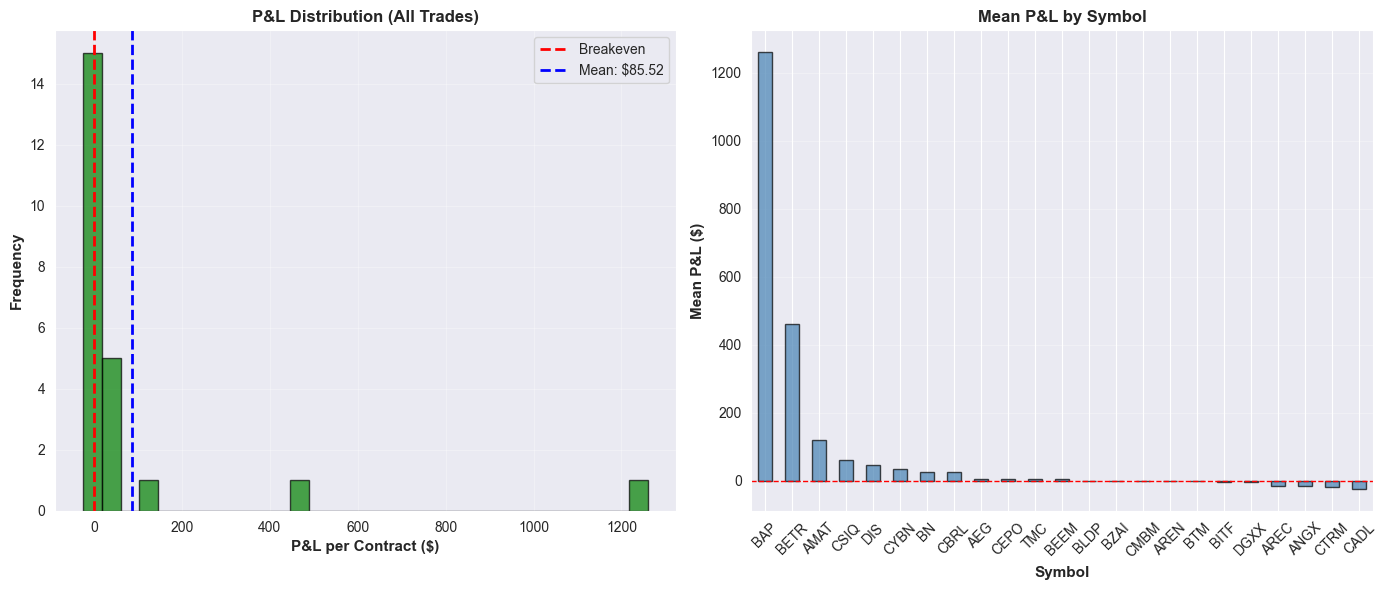

In [5]:
if len(results_df) > 0:
    # Create visualization using library function
    fig = create_strategy_summary_plot(
        results_df,
        pnl_column='pnl_per_contract',
        group_by='symbol',
        figsize=(14, 6)
    )
    plt.show()
else:
    print("⚠️  No data to plot")

## 4. Results by Symbol

In [6]:
if len(results_df) > 0:
    # Create by-symbol summary using library function
    by_symbol = create_by_symbol_summary(results_df, pnl_column='pnl_per_contract')
    print("Results by Symbol:")
    print(by_symbol)
else:
    print("⚠️  No data to analyze")

Results by Symbol:
        Count  Mean P&L  Median P&L  Std Dev  Entry Cost  Return %
symbol                                                            
BAP         1    1260.0      1260.0      NaN       250.0    504.00
BETR        1     460.0       460.0      NaN       630.0     73.02
AMAT        1     118.0       118.0      NaN       190.0     62.11
CSIQ        1      60.0        60.0      NaN        50.0    120.00
DIS         1      47.0        47.0      NaN        25.0    188.00
CYBN        1      35.0        35.0      NaN        15.0    233.33
BN          1      25.0        25.0      NaN        35.0     71.43
CBRL        1      25.0        25.0      NaN       155.0     16.13
AEG         1       5.0         5.0      NaN        15.0     33.33
CEPO        1       5.0         5.0      NaN         5.0    100.00
TMC         1       5.0         5.0      NaN        15.0     33.33
BEEM        1       5.0         5.0      NaN        10.0     50.00
BLDP        1       0.0         0.0      Na

## 5. Conclusions

Based on the backtest results above, we can draw conclusions about:

1. **Overall Profitability**: Is the calendar spread strategy profitable across earnings events?
2. **Consistency**: How consistent are the returns? (std dev, win rate)
3. **Symbol-Specific**: Do certain symbols work better than others?
4. **Exit Timing**: Exiting after earnings (capturing IV crush) vs other strategies

In [7]:
# Save results for further analysis
if len(results_df) > 0:
    results_df.to_csv('calendar_spread_backtest_results.csv', index=False)
    print(f"✅ Results saved to calendar_spread_backtest_results.csv ({len(results_df)} trades)")
else:
    print("⚠️  No results to save")

✅ Results saved to calendar_spread_backtest_results.csv (23 trades)
